# Task 1 - Sentiment Analysis

## 1. Introduction

In [2]:
!git clone https://github.com/nicoholth/INFO284Semesterassignment.git

Cloning into 'INFO284Semesterassignment'...
remote: Enumerating objects: 1177, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 1177 (delta 14), reused 9 (delta 5), pack-reused 1156 (from 1)
Receiving objects: 100% (1177/1177), 1.62 GiB | 26.57 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Updating files: 100% (988/988), done.


In [3]:
import os
os.chdir("INFO284Semesterassignment")

In [4]:
!ls

data  README.md  requirements.txt  Semesterassignment.ipynb  Task1_Sentiment


## 2. Exploratory Data Analysis (EDA)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [7]:
df = pd.read_csv("data/reviews.csv")

df.head()

,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


In [9]:
df.describe()

,rating,helpful
count,6210.000000,6210.000000
mean,3.490016,43.463607
std,1.703590,3161.807086
min,1.000000,0.000000
25%,1.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,5.000000,248962.000000


In [10]:
df["rating"].value_counts()

,count
rating,
5,3021
1,1582
4,632
3,508
2,467


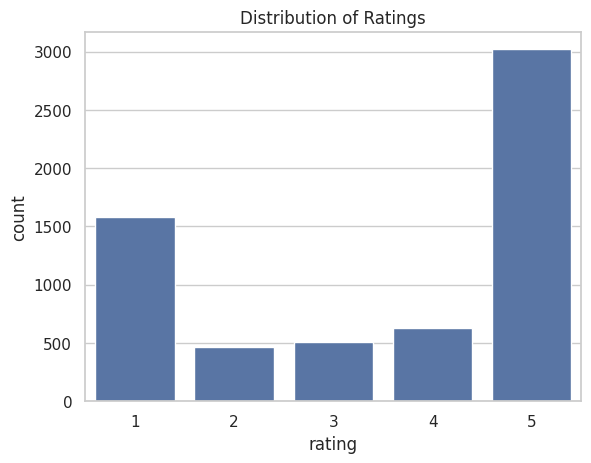

In [11]:
sns.countplot(x="rating", data=df)
plt.title("Distribution of Ratings")
plt.show()

The dataset contains 6210 reviews. There are 1582 1-star reviews, 467 2-star reviews, 508 3-star reviews, 632 4-star reviews and 3021 5-star reviews. This shows a bit of imbalanced distribution. The imbalance may have an effect on how the model preforms, especially if accuracy score is the only metric considered.

In [12]:
df["review_length"] = df["review_text"].str.len()

df["review_length"].describe()

,review_length
count,6210.000000
mean,93.598390
std,130.661464
min,3.000000
25%,22.000000
50%,44.000000
75%,100.000000
max,1260.000000


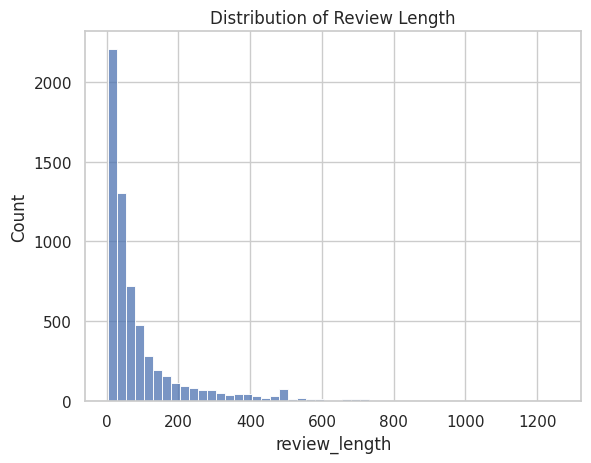

In [13]:
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.show()

The average length of the reviews are 93 characters. The standar deviation is aproximately 131. This idicates that there is a large variation in length. Many are short, and some are very long. This variability may influence preproceccing decisions.

In [14]:
df["review_text"].isnull().sum()

np.int64(0)

In [15]:
(df["review_text"].str.strip() == "").sum()

np.int64(0)

None of the reviews are empty, and it's not nessasary to remove any rows.

## 3. Preprocessing

In this step the text is cleaned before feature extaction.

In [16]:
df["review_text"] = df["review_text"].str.lower()

In [17]:
import re

df["review_text"] = df["review_text"].apply(lambda x: re.sub(r"[^\w\s]", "", x))

In [18]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [19]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [21]:
df["review_text"] = df["review_text"].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

## 4. Feature Engineering

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

In [24]:
X = vectorizer.fit_transform(df["review_text"])

In [25]:
y = df["rating"]

In [26]:
X.shape

(6210, 5000)

TF-IDF vectorization converts the review texts into numerical features. Each review is represented as a vector where the values reflect the importance of words in the dataset. This allows machine learning models to process textual data.

## 5. Models

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train.shape

(4968, 5000)

The dataset is split into training and test sets in order to evaluate model performance on unseen data.

### 5.1 Model 1 - Logistic Regression (Classification)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
accuracy

0.5869565217391305

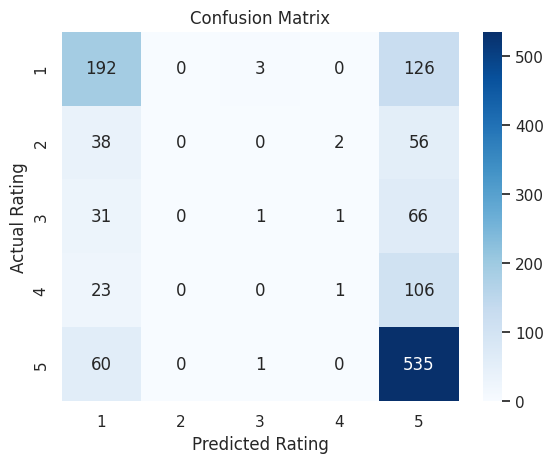

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Confusion Matrix")
plt.show()

The model preforms well for the most frequent classes, in this case ratings 1 and 5, but struggles to predict the middle ratings. This is most likley due to imbalance in the dataset.

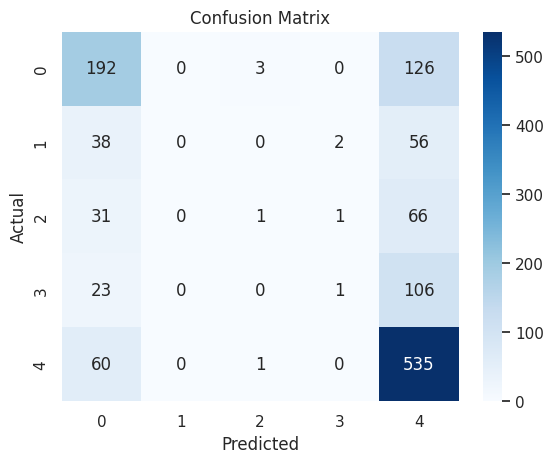

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 5.2 Model 2 Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestRegressor

Importerer Random Forest Classifier modellen fra sckit-learn.

In [35]:
rf = RandomForestClassifier(n_estimators=300,max_depth=20, class_weight="balanced", random_state=42,n_jobs=-1)


Oppretter modellen med antall trær i skogen lik 100.

In [36]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.51      0.61      0.56       321
           2       0.09      0.02      0.03        96
           3       0.07      0.07      0.07        99
           4       0.17      0.33      0.22       130
           5       0.79      0.64      0.71       596

    accuracy                           0.51      1242
   macro avg       0.33      0.34      0.32      1242
weighted avg       0.54      0.51      0.52      1242



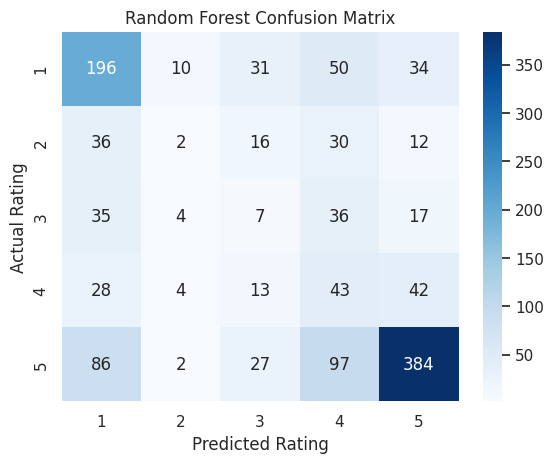

In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5])

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Random Forest Confusion Matrix")
plt.show()

This code creates a confusion matrix for the Random Forest model by comparing the values in y_test, with the models predictions in y_pred_rf. The matrix shows how many observasions were classified correctly, and which classes the model may be confusing with each other. Next, sns.heatmap() from Seaborn is used to visualize the matrix as a heatmap, where darker blue colours represent a high number of obervations. This makes it easy to see how well the model performs and which rating classes it most often mixes up.

In [38]:
rfr = RandomForestRegressor(n_estimators=300, random_state=42)


In [40]:
rfr.fit(X_train, y_train)

y_pred_rfr = rfr.predict(X_test)
y_pred_rfr = np.round(y_pred_rfr).clip(1, 5)


KeyboardInterrupt: 

In [ ]:
cmr = confusion_matrix(y_test, y_pred_rfr)

In [ ]:
sns.heatmap(
    cmr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5])

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Random Forest Regressor Confusion Matrix")
plt.show()

We also tried using the "Random Forest Regressor" model and found some interesting results.

### 5.3 Model 3 Linear Regression (Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lin_model = LinearRegression()

In [ ]:
lin_model.fit(X_train, y_train)

In [ ]:
lin_predictions = lin_model.predict(X_test)

In [ ]:
import numpy as np

lin_predictions_rounded = np.round(lin_predictions)
lin_predictions_rounded = np.clip(lin_predictions_rounded, 1, 5)

In [ ]:
lin_accuracy = accuracy_score(y_test, lin_predictions_rounded)
lin_accuracy

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, lin_predictions)
mae = mean_absolute_error(y_test, lin_predictions)

mse, mae

In [ ]:
cm = confusion_matrix(y_test, lin_predictions_rounded)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1,2,3,4,5],
    yticklabels=[1,2,3,4,5]
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Linear Regression Confusion Matrix")
plt.show()

### 5.4 Model 4 LSTM Nerual Network

First we need to create Tokenization as TF-IDF can not be used directly with LSTM. LSTM needs Sequential ordering of the words not, bag-of-words.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Bidirectional

In [ ]:
max_words = 10000
max_len = 300

We changed max length from 100 to 300 so there isnt any data lost seeing ase some reviews might be quite long.

In [ ]:
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df["review_text"])

In [ ]:
sequences = tokenizer.texts_to_sequences(df["review_text"])
X_seq = pad_sequences(sequences, maxlen=max_len)

Create categorical classifications for the ratings 1-5.

In [ ]:

from tensorflow.keras.utils import to_categorical

In [ ]:
y = to_categorical(df["rating"] - 1)  # gjør om 1–5 → 0–4

Create train/test split.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

In [ ]:
# Embedding layer
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

# LSTM layer
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# Regularization
model.add(Dropout(0.5))

# Output layer (5 klasser)
model.add(Dense(5, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()




history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Evaluation

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

## 6. Evaluation

## 7. Discussion

## 8. Conclusion

# Task 2

In [42]:
!ls data/Art_shuffled/

AiArtData  RealArt


## Task 2 a

In [43]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "data/Art_shuffled",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "data/Art_shuffled",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 752 images belonging to 2 classes.
Found 186 images belonging to 2 classes.


In [44]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [45]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [46]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5518 - loss: 0.7864

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


24/24 ━━━━━━━━━━━━━━━━━━━━ 114s 4s/step - accuracy: 0.5864 - loss: 0.7132 - val_accuracy: 0.7151 - val_loss: 0.5510
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.7753 - loss: 0.4621 - val_accuracy: 0.7097 - val_loss: 0.5339
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.8338 - loss: 0.3749 - val_accuracy: 0.7634 - val_loss: 0.5152
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.8657 - loss: 0.3409 - val_accuracy: 0.7796 - val_loss: 0.5052
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.9016 - loss: 0.2621 - val_accuracy: 0.7849 - val_loss: 0.5173


In [48]:
loss, accuracy = model.evaluate(val_data)
print("Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7849 - loss: 0.5173
Accuracy: 0.7849462628364563


## Task 2 b

In [53]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(path):
    img = image.load_img(path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        print("AI generated")
    else:
        print("Human created")

In [54]:
!ls data/Own_images

 731905376985592520.jpg
'૮ •〃• ა_ ★.jpg'
'ChatGPT Image 20. apr. 2026, 12_54_49.png'
'ChatGPT Image 20. apr. 2026, 12_55_44.png'
'ChatGPT Image 20. apr. 2026, 12_57_34.png'


In [55]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
import os

def predict_image(path):
    img = image.load_img(path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    label = "AI generated" if prediction > 0.5 else "Human created"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Show image
    plt.imshow(img)
    plt.title(f"{label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


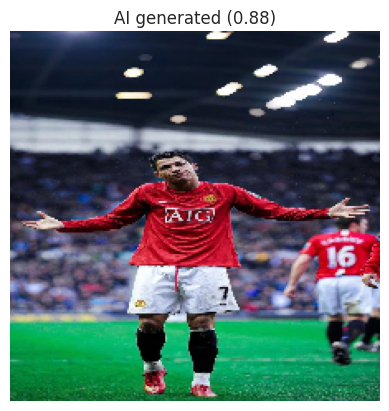

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


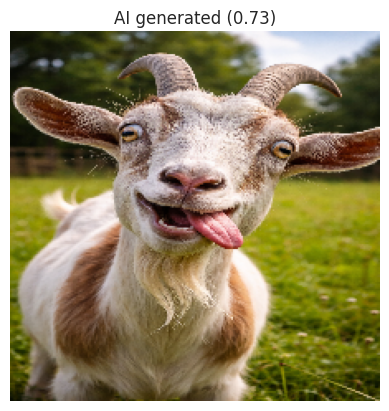

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


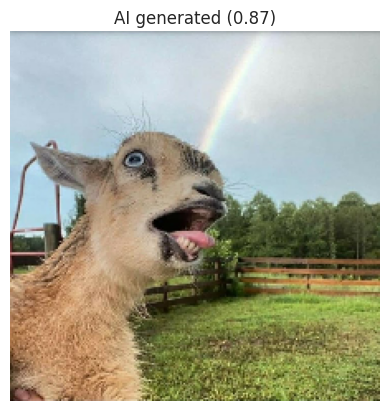

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


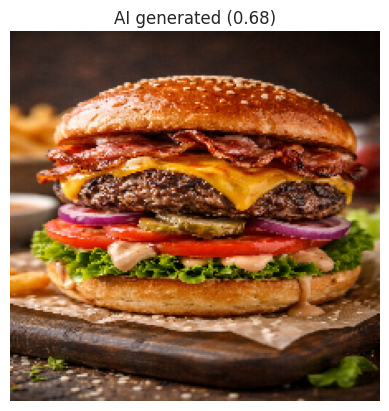

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


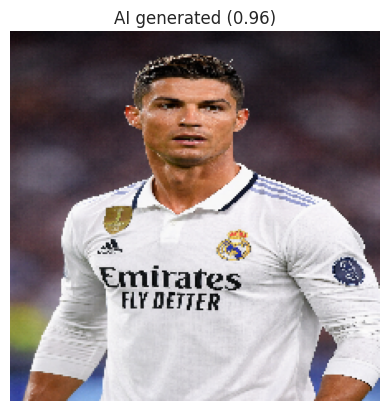

In [56]:
folder = "data/Own_images"

for img in os.listdir(folder):
    predict_image(os.path.join(folder, img))